# Preprocessing

In [4]:
import pandas as pd

test_pairs = pd.read_csv("test_pairs.csv")
train = pd.read_csv("train.csv")
users = pd.read_csv("users.csv")
movies = pd.read_csv("movies.csv")

print("Shape of training data:", train.shape)
print("Shape of test pair data", test_pairs.shape)
print("Shape of user metadata", users.shape)
print("Movies:", movies.shape)



Shape of training data: (797758, 4)
Shape of test pair data (202451, 2)
Shape of user metadata (6040, 4)
Movies: (3883, 4)


In [5]:
# Check for duplicates and null values
print("Duplicates:", train.duplicated().sum())
print("NULL:", train.isnull().sum())
print("Duplicates:", users.duplicated().sum())
print("NULL:", users.isnull().sum())
print("Duplicates:", movies.duplicated().sum())
print("NULL:", movies.isnull().sum())


Duplicates: 0
NULL: user_id      0
item_id      0
rating       0
timestamp    0
dtype: int64
Duplicates: 0
NULL: user_id       0
gender        0
age_group     0
occupation    0
dtype: int64
Duplicates: 0
NULL: item_id    0
title      0
year       0
genres     0
dtype: int64


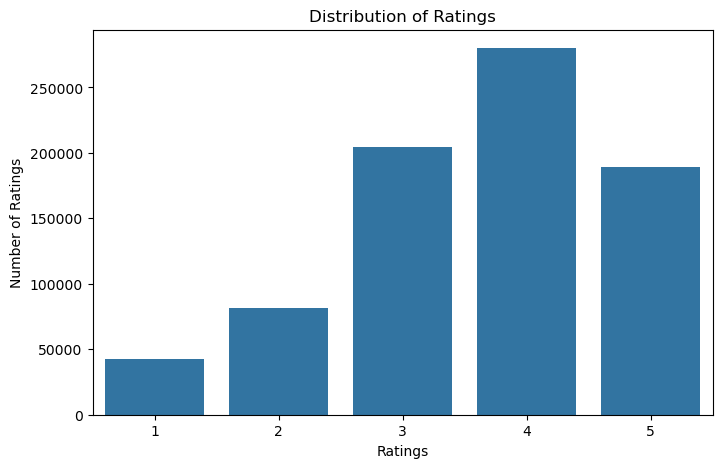

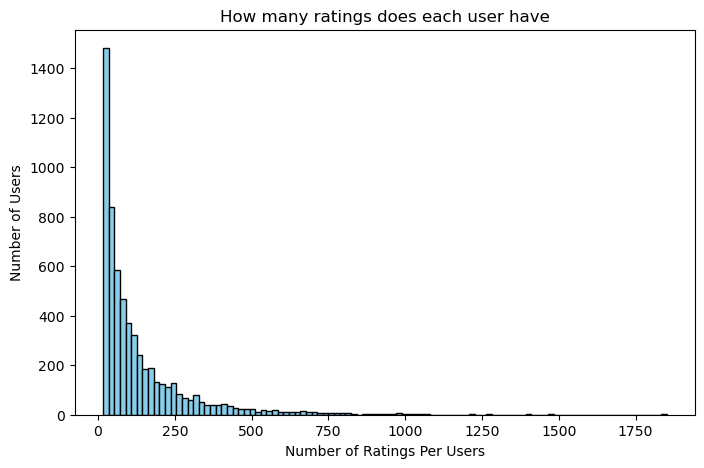

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the user distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=train)
plt.title('Distribution of Ratings')
plt.xlabel('Ratings')
plt.ylabel('Number of Ratings')
plt.show()

# Plot how many ratings per user
user_counts = train.groupby('user_id').size()
plt.figure(figsize=(8, 5))
plt.hist(user_counts, bins=100, color='skyblue', edgecolor='black')
plt.title('How many ratings does each user have')
plt.xlabel('Number of Ratings Per Users')
plt.ylabel('Number of Users')
plt.show()

In [7]:
# Look at the distrbution of all ratings in training dataset
train.describe()
print(train['rating'].value_counts())

rating
4    280133
3    204611
5    189059
2     81748
1     42207
Name: count, dtype: int64


We need to create an 80:20 temporal split, as well as calculate how many ratings 20% is for every single user and then sort their ratings by timestamps. Thought it seems like 

In [8]:
import numpy as np

#Create the 80:20 temporal split as described in the discussion
def temporal_split(df, test_ratio=0.20):
    # Sort each user's rating by time
    df = df.sort_values(['user_id', 'timestamp'], ascending=[True, True], kind='stable')

    # Create the training set and validation set
    train_split = []
    val_split = []
    for user_id, group in df.groupby('user_id'):
        ratings_count = len(group)

        # Calculate how many rating we should keep
        test_count = int(np.ceil(test_ratio * ratings_count))
        train_count = ratings_count - test_count

        # Map the positions back to the original dataframe indices
        user_set = group.index.tolist()

        # Create the training and validation test
        train_split.extend(user_set[:train_count])
        val_split.extend(user_set[train_count:])

    # Create data frame
    train_df = df.loc[train_split].copy()
    val_df = df.loc[val_split].copy()

    return train_df, val_df


Created a baseline, to compare with the Collaborative Filtering model. The global mean of all the user rating was used just as comparison to see what it would predict.

In [9]:
from baseline_global_mean import predict as predict_baseline
from evaluation_code import rmse

train_df, val_df = temporal_split(train)
val_baseline_preds = predict_baseline(train_df, val_df)

ground_truth = val_df[['user_id', 'item_id', 'rating']]
score = rmse(ground_truth, val_baseline_preds)

print(f"Baseline RMSE: {score}")


Baseline RMSE: 1.1199807813370257


In [10]:
used_mean = train_df["rating"].mean()
val_mean = val_df["rating"].mean()
print(f"Mean used for baseline: {used_mean}")
print(f"Val mean: {val_mean}")
print(f"Mean difference: {abs(used_mean - 3.61684)}")
print("Train_df", train_df.shape)
print("Val_df", val_df.shape)
val_df.describe
print(val_df['rating'].value_counts())
train_df.describe
print(train_df['rating'].value_counts())

Mean used for baseline: 3.643977015146534
Val mean: 3.510371216095288
Mean difference: 0.027137015146533994
Train_df (635723, 4)
Val_df (162035, 4)
rating
4    57096
3    44676
5    31900
2    18528
1     9835
Name: count, dtype: int64
rating
4    223037
3    159935
5    157159
2     63220
1     32372
Name: count, dtype: int64


# Neighborhood Collborative Filtering

In [11]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

def get_item_similarity(train_df):
    user_map = {id: i for i, id in enumerate(train_df['user_id'].unique())}
    item_map = {id: i for i, id in enumerate(train_df['item_id'].unique())}
    
    # Create the CSR matrix 
    row = train_df['user_id'].map(user_map).values
    col = train_df['item_id'].map(item_map).values
    data = train_df['rating'].values
    matrix = csr_matrix((data, (row, col)), shape=(len(user_map), len(item_map)))
    
    # Compute item item similarity
    item_sim = cosine_similarity(matrix.T, dense_output=False)
    
    return item_sim, user_map, item_map, matrix

In [12]:
def predict_neighborhood(train, test_pairs, k=40):
    item_sim, user_map, item_map, matrix = get_item_similarity(train)
    global_mean = train["rating"].mean()
    
    predictions = []
    
    for _, row in test_pairs.iterrows():
        user_id, item_id = row['user_id'], row['item_id']
        
        #If cold start then just append global mean
        if item_id not in item_map or user_id not in user_map:
            predictions.append(global_mean)
            continue
            
        user_idx = user_map[user_id]
        item_idx = item_map[item_id]
        
        # Get similarities for target item 
        sim_vector = item_sim[item_idx].toarray().flatten()
        user_ratings = matrix[user_idx].toarray().flatten()
        
        # Find items the user has actually rated
        rated_mask = user_ratings > 0
        weights = sim_vector[rated_mask]
        ratings = user_ratings[rated_mask]
        
        if len(weights) > 0:
            # Sort and pick top K neighbors
            top_indices = np.argsort(weights)[-k:]
            top_weights = weights[top_indices]
            top_ratings = ratings[top_indices]
            
            sum_weights = np.sum(np.abs(top_weights))
            # Using tolerance of 1e-9 to stay above double pre
            if sum_weights > 1e-9:
                pred = np.sum(top_weights * top_ratings) / sum_weights
            else:
                pred = global_mean
        else:
            pred = global_mean
            
        predictions.append(pred)

    out = test_pairs[["user_id", "item_id"]].copy()
    out["predicted_rating"] = np.clip(predictions, 1.0, 5.0)
    return out

In [13]:
results = {}
k_to_test = [12, 14, 15, 17, 19, 20]
val_ground_truth = val_df[['user_id', 'item_id', 'rating']]
val_query_pairs = val_df[['user_id', 'item_id']]

for k in k_to_test:
    print(f"Testing K = {k}...")
    preds = predict_neighborhood(train_df, val_query_pairs, k=k)
    score = rmse(val_ground_truth, preds)
    results[k] = score
    print(f"Result for K={k}: RMSE = {score}")

best_k = min(results, key=results.get)
print(f"K={best_k} with RMSE: {results[best_k]}")

Testing K = 12...
Result for K=12: RMSE = 0.9873459531838281
Testing K = 14...
Result for K=14: RMSE = 0.9862898045466243
Testing K = 15...
Result for K=15: RMSE = 0.9863118660262339
Testing K = 17...
Result for K=17: RMSE = 0.9863396291545857
Testing K = 19...
Result for K=19: RMSE = 0.9868439076108941
Testing K = 20...
Result for K=20: RMSE = 0.9870257999993202
K=14 with RMSE: 0.9862898045466243


# Funk SVD


In [15]:
unique_users = train_df['user_id'].unique()
unique_items = train_df['item_id'].unique()

# create a map
unique_users =train_df['user_id'].unique()
unique_items = train_df['item_id'].unique()

user_map = {user_id: i for i, user_id in enumerate(unique_users)}
item_map = {item_id: i for i, item_id in enumerate(unique_items)}
n_users = len(user_map)
n_items = len(item_map)
mu = train_df['rating'].mean()

# Used AI (Gemini): To try to make this run faster
train_data = []
for row in train_df.itertuples():
    if row.user_id in user_map and row.item_id in item_map:
        train_data.append((user_map[row.user_id], item_map[row.item_id], row.rating))


In [21]:
def funk_svd(K, beta, alpha, epochs, train_data, val_df):
    
    P = np.random.normal(0, 0.1, (n_users, K))
    Q = np.random.normal(0, 0.1, (n_items, K))
    bu = np.zeros(n_users)
    bi = np.zeros(n_items)
    # Initialize parameters for this specific experiment
    val_history = []
    
    for epoch in range(epochs):
        # Run SGD
        np.random.shuffle(train_data)
        
        # Training loop based on discussion slides
        for u, i, r_ui in train_data:
            prediction = mu + bu[u] + bi[i] + np.dot(P[u], Q[i])
            error = r_ui - prediction
            
            # Update biases and latent factors
            bu[u] += alpha * (error - beta * bu[u])
            bi[i] += alpha * (error - beta * bi[i])
            
            old_p_u = P[u].copy()
            P[u] += alpha * (error * Q[i] - beta * P[u])
            Q[i] += alpha * (error * old_p_u - beta * Q[i])
        
        # Create a validation check
        preds = []
        for row in val_df.itertuples():
            if row.user_id in user_map and row.item_id in item_map:
                u_idx, i_idx = user_map[row.user_id], item_map[row.item_id]
                res = mu + bu[u_idx] + bi[i_idx] + np.dot(P[u_idx], Q[i_idx])
            else:
                res = mu 
            preds.append(res)
        
        curr_rmse = rmse(val_df[['user_id', 'item_id', 'rating']], 
                                pd.DataFrame({'user_id': val_df['user_id'], 
                                              'item_id': val_df['item_id'], 
                                              'predicted_rating': np.clip(preds, 1.0, 5.0)}))
        val_history.append(curr_rmse)
        print(f"  Epoch {epoch+1}/{epochs} | Val RMSE: {curr_rmse}")
        
    return val_history



Running Experiment: K=20, Beta=0.02, Alpha =0.005
  Epoch 1/30 | Val RMSE: 0.9604682361211029
  Epoch 2/30 | Val RMSE: 0.936717164081595
  Epoch 3/30 | Val RMSE: 0.927393745666474
  Epoch 4/30 | Val RMSE: 0.92257193931638
  Epoch 5/30 | Val RMSE: 0.9195149962118998
  Epoch 6/30 | Val RMSE: 0.9173216542054974
  Epoch 7/30 | Val RMSE: 0.9156860426603559
  Epoch 8/30 | Val RMSE: 0.9139687810320372
  Epoch 9/30 | Val RMSE: 0.9120883854366688
  Epoch 10/30 | Val RMSE: 0.9096613759138311
  Epoch 11/30 | Val RMSE: 0.9071643743248966
  Epoch 12/30 | Val RMSE: 0.903989548190301
  Epoch 13/30 | Val RMSE: 0.9017711036269005
  Epoch 14/30 | Val RMSE: 0.8990072841486092
  Epoch 15/30 | Val RMSE: 0.8968485015435534
  Epoch 16/30 | Val RMSE: 0.8946603894345087
  Epoch 17/30 | Val RMSE: 0.8927464484983425
  Epoch 18/30 | Val RMSE: 0.8912633882463411
  Epoch 19/30 | Val RMSE: 0.8897894894258458
  Epoch 20/30 | Val RMSE: 0.8888765952582822
  Epoch 21/30 | Val RMSE: 0.8881577913155051
  Epoch 22/30 | Va

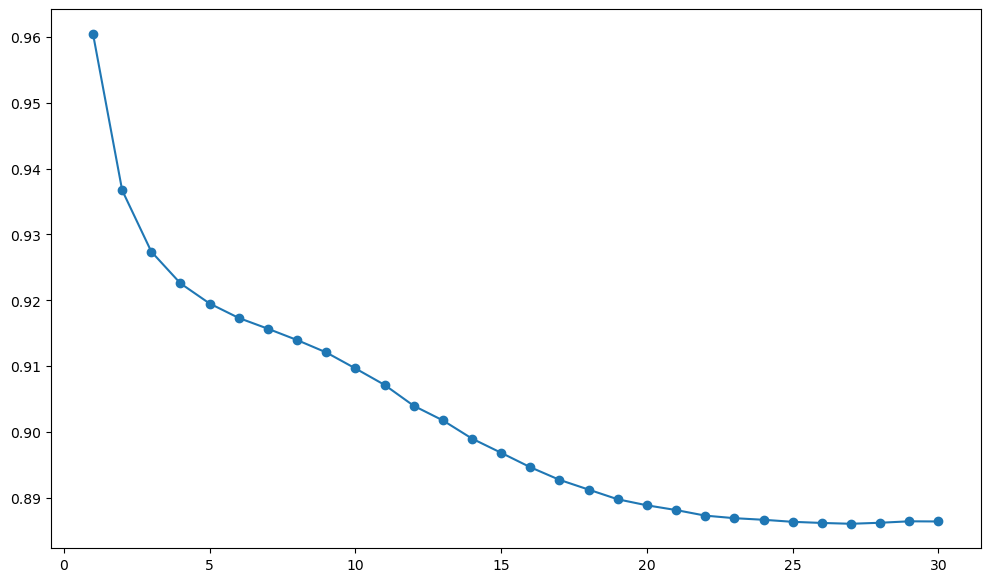

In [22]:
# Initialize grid search and plot them
k_arr = [20]
beta_arr = [0.02]
alpha_arr = [0.005]
epochs = 30

plt.figure(figsize=(12, 7))

for k in k_arr:
    for b in beta_arr:
        for a in alpha_arr:
            label = f"K={k}, Beta={b}, Alpha ={a}"
            print(f"\nRunning Experiment: {label}")
            history = funk_svd(k, b, a, epochs, train_data, val_df)
            plt.plot(range(1, epochs + 1), history, label=label, marker='o')


# Hyrbidization Attempt

In [ ]:
unique_users = train_df['user_id'].unique()
unique_items = train_df['item_id'].unique()

user_map = {user_id: i for i, user_id in enumerate(unique_users)}
item_map = {item_id: i for i, item_id in enumerate(unique_items)}
n_users, n_items = len(user_map), len(item_map)
mu = train_df['rating'].mean()

# Load movies and map them to their genres 
movies = pd.read_csv('movies.csv')
item_to_genre = movies.set_index('item_id')['genres'].to_dict()
train_with_genres = train_df.merge(movies, on='item_id')
genre_means = train_with_genres.groupby('genres')['rating'].mean().to_dict()

K = 20
alpha = 0.005
beta = 0.02
epochs = 30
P = np.random.normal(0, 0.1, (n_users, K))
Q = np.random.normal(0, 0.1, (n_items, K))
bu = np.zeros(n_users)
bi = np.zeros(n_items)
train_data = []
for row in train_df.itertuples():
    if row.user_id in user_map and row.item_id in item_map:
        train_data.append((user_map[row.user_id], item_map[row.item_id], row.rating))
val_history = []



# SGD For Funk SVG
for epoch in range(epochs):
    np.random.shuffle(train_data)
    for u, i, r_ui in train_data:
        prediction = mu + bu[u] + bi[i] + np.dot(P[u], Q[i])
        error = r_ui - prediction
        bu[u] += alpha * (error - beta * bu[u])
        bi[i] += alpha * (error - beta * bi[i])
        
        old_p_u = P[u].copy()
        P[u] += alpha * (error * Q[i] - beta * P[u])
        Q[i] += alpha * (error * old_p_u - beta * Q[i])
    
    val_preds_list = []
    for row in val_df.itertuples():
        u_id, i_id = row.user_id, row.item_id
        
        # Cold start with hyrbidization
        if u_id not in user_map or i_id not in item_map:
            genre = item_to_genre.get(i_id)
            val_preds_list.append(genre_means.get(genre, mu))
        else:
            u_idx, i_idx = user_map[u_id], item_map[i_id]
            res = mu + bu[u_idx] + bi[i_idx] + np.dot(P[u_idx], Q[i_idx])
            val_preds_list.append(res)
            
    val_df_scored = val_df[['user_id', 'item_id', 'rating']].copy()
    val_df_scored['predicted_rating'] = np.clip(val_preds_list, 1.0, 5.0)
    
    # Calculate rmse for each epoch
    curr_rmse = rmse(val_df[['user_id', 'item_id', 'rating']], val_df_scored)
    val_history.append(curr_rmse)
    print(f"Epoch {epoch+1}/{epochs} | Val RMSE: {curr_rmse}")

Epoch 1/30 | Val RMSE: 0.960797873816536
Epoch 2/30 | Val RMSE: 0.9368277776751384
Epoch 3/30 | Val RMSE: 0.9272243185011292
Epoch 4/30 | Val RMSE: 0.9223458546794486
Epoch 5/30 | Val RMSE: 0.9195276146070642
Epoch 6/30 | Val RMSE: 0.9176247675552857
Epoch 7/30 | Val RMSE: 0.9158455609627248
Epoch 8/30 | Val RMSE: 0.9148459137465605
Epoch 9/30 | Val RMSE: 0.9130735877474437
Epoch 10/30 | Val RMSE: 0.9113310946860145
Epoch 11/30 | Val RMSE: 0.9092382149622181
Epoch 12/30 | Val RMSE: 0.90670693784589
Epoch 13/30 | Val RMSE: 0.9037937004560516
Epoch 14/30 | Val RMSE: 0.9014985688457873
Epoch 15/30 | Val RMSE: 0.8985559175243093
Epoch 16/30 | Val RMSE: 0.8965508060342022
Epoch 17/30 | Val RMSE: 0.8946823449687338
Epoch 18/30 | Val RMSE: 0.8929764646506837
Epoch 19/30 | Val RMSE: 0.8913218501690159
Epoch 20/30 | Val RMSE: 0.8901904212833021
Epoch 21/30 | Val RMSE: 0.8892600927761635
Epoch 22/30 | Val RMSE: 0.888457840048216
Epoch 23/30 | Val RMSE: 0.8879028921146529
Epoch 24/30 | Val RMSE: 

In [ ]:
from baseline_global_mean import predict

full_train = pd.concat([train_df, val_df])
submission = predict(full_train, test_pairs)
submission.to_csv("submission.csv", index=False)
